# Assignment 0

In [1]:

import pandas as pd
import numpy as np
from pandas.core.reshape import concat
from scipy.spatial.distance import mahalanobis
from scipy.spatial.distance import euclidean


test_in = pd.read_csv(r"data/test_in - Copy.csv",header=None)
test_out = pd.read_csv(r"data/test_out - Copy.csv",header=None)
test_out = test_out.rename(columns={0:"label"})
train_in = pd.read_csv(r"data/train_in - Copy.csv",header=None)
train_out = pd.read_csv(r"data/train_out - Copy.csv",header=None)
train_out = train_out.rename(columns={0:"label"})
train_set = pd.concat([train_in,train_out],axis=1)
test_set = pd.concat([test_in,test_out],axis=1)


# Implementing centroid classification

In [2]:
centroids = train_set.groupby("label").mean()
results = []
digits = range(10)

x = train_in
y = train_set["label"]
c = centroids

matching_centroids = c.loc[y].set_axis(x.index)
train_in_mahalanobis = x - matching_centroids

inverse_of_cov = np.linalg.inv(train_in_mahalanobis.cov())

for _, row in test_set.iterrows():
    predicted_mahalanobis_label = None
    predicted_euclidean_label = None
    smallest_mahalanobis_distance = float("inf")
    smallest_euclidean_distance = float("inf")

    for _, cent in centroids.iterrows():
        dist_mahalanobis = mahalanobis(row.iloc[:-1], cent, inverse_of_cov)
        dist_euclidean = euclidean(row.iloc[:-1], cent)
        label = cent.name

        if dist_mahalanobis < smallest_mahalanobis_distance:
            smallest_mahalanobis_distance = dist_mahalanobis
            predicted_mahalanobis_label = label
        if dist_euclidean < smallest_euclidean_distance:
            smallest_euclidean_distance = dist_euclidean
            predicted_euclidean_label = label

    results.append({"prediction_mahalanobis": predicted_mahalanobis_label, "distance_mahalanobis": smallest_mahalanobis_distance,  "prediction_euclidean": predicted_euclidean_label, "distance_euclidean": smallest_euclidean_distance})

prediction_and_distances = pd.DataFrame(results)
test_set = pd.concat([test_set,prediction_and_distances],axis=1)


accuracy_euclidean = (test_set["label"] == test_set["prediction_euclidean"]).mean()
accuracy_mahalanobis = (test_set["label"] == test_set["prediction_mahalanobis"]).mean()
print("Euclidean accuracy:\t",accuracy_euclidean,"\nMahalanobis accuracy:",accuracy_mahalanobis)



Euclidean accuracy:	 0.804 
Mahalanobis accuracy: 0.88


# Centroid classification and accuracy using two different distance metrics

In [3]:
results_train = []

for _, row in train_set.iterrows():
    predicted_mahalanobis_label = None
    predicted_euclidean_label = None
    smallest_mahalanobis_distance = float("inf")
    smallest_euclidean_distance = float("inf")

    for _, cent in centroids.iterrows():
        dist_mahalanobis = mahalanobis(row.iloc[:-1], cent, inverse_of_cov)
        dist_euclidean = euclidean(row.iloc[:-1], cent)
        label = cent.name

        if dist_mahalanobis < smallest_mahalanobis_distance:
            smallest_mahalanobis_distance = dist_mahalanobis
            predicted_mahalanobis_label = label
        if dist_euclidean < smallest_euclidean_distance:
            smallest_euclidean_distance = dist_euclidean
            predicted_euclidean_label = label

    results_train.append({"prediction_mahalanobis": predicted_mahalanobis_label, "distance_mahalanobis": smallest_mahalanobis_distance,  "prediction_euclidean": predicted_euclidean_label, "distance_euclidean": smallest_euclidean_distance})

prediction_and_distances_train = pd.DataFrame(results_train)
train_set = pd.concat([train_set,prediction_and_distances_train],axis=1)


accuracy_euclidean_train = (train_set["label"] == train_set["prediction_euclidean"]).mean()
accuracy_mahalanobis_train = (train_set["label"] == train_set["prediction_mahalanobis"]).mean()
print("Euclidean accuracy:\t",accuracy_euclidean_train,"\nMahalanobis accuracy:",accuracy_mahalanobis_train)

Euclidean accuracy:	 0.8635032220269478 
Mahalanobis accuracy: 0.9689513766842414


# identifying harder digits to tell apart

In [4]:
from scipy.spatial.distance import cdist,pdist
from itertools import combinations

labels = combinations(digits,2)
labels = pd.DataFrame(labels)
labels = labels.rename(columns={0:"label1",1:"label2"})

centroids_distances_euclidean = pd.DataFrame(pdist(centroids,metric="euclidean"))
centroids_distances_euclidean[["label1","label2"]] = labels[["label1","label2"]]
centroids_distances_euclidean = centroids_distances_euclidean.rename(columns={0:"dist"})

centroids_distances_mahalanobis = pd.DataFrame(pdist(centroids,metric="mahalanobis",VI=inverse_of_cov))
centroids_distances_mahalanobis[["label1","label2"]] = labels[["label1","label2"]]
centroids_distances_mahalanobis = centroids_distances_mahalanobis.rename(columns={0:"dist"})


centroids_distances_mahalanobis.nsmallest(5,"dist")

,dist,label1,label2
43,5.709611,7,9
34,6.114444,4,9
33,7.025403,4,8
22,7.037856,2,8
37,7.093449,5,8


In [5]:
centroids_distances_euclidean.nsmallest(5,"dist")


,dist,label1,label2
43,5.426474,7,9
34,6.010408,4,9
25,6.118750,3,5
44,6.401166,8,9
35,6.698692,5,6


# Identifying the labels which are harder to distinguish

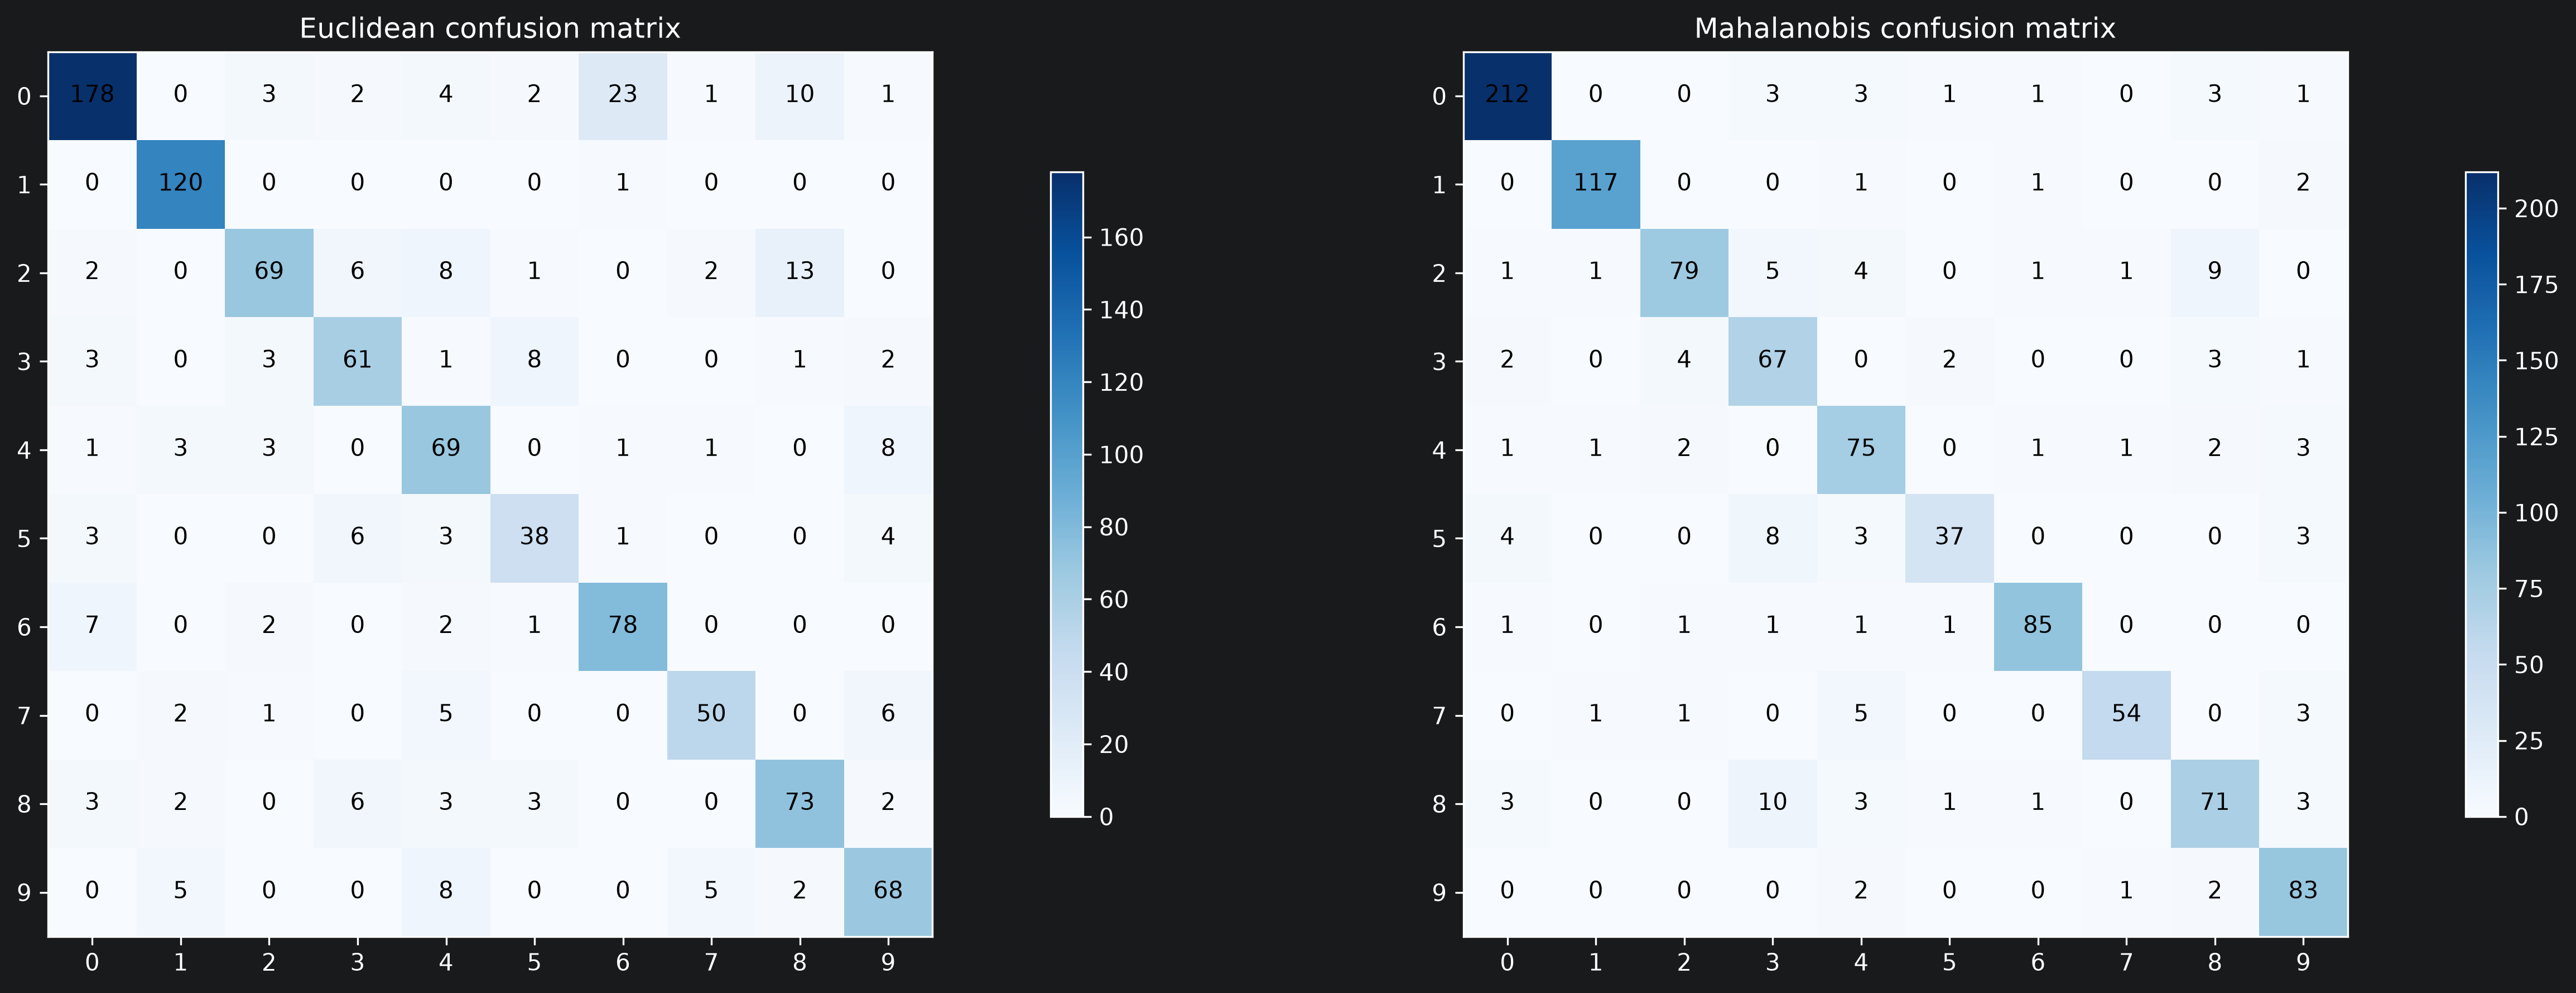

In [6]:
confusion_matrix_euclid = pd.crosstab(test_set["label"], test_set["prediction_euclidean"])
confusion_matrix_mahala = pd.crosstab(test_set["label"], test_set["prediction_mahalanobis"])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2,figsize=(20,10))

picture_euclid = axes[0].imshow(confusion_matrix_euclid,cmap=plt.cm.Blues)
axes[0].set_xticks(digits)
axes[0].set_yticks(digits)
for x in digits:
    for y in digits:
        axes[0].text(x,y,confusion_matrix_euclid.iloc[y,x],color="black",ha="center",va="center")
fig.colorbar(picture_euclid, ax=axes[0],pad=0.1,shrink=0.5)
axes[0].set_title("Euclidean confusion matrix")

picture_mahala = axes[1].imshow(confusion_matrix_mahala,cmap=plt.cm.Blues)
axes[1].set_xticks(digits)
axes[1].set_yticks(digits)
for x in digits:
    for y in digits:
        axes[1].text(x,y,confusion_matrix_mahala.iloc[y,x],color="black",ha="center",va="center")
fig.colorbar(picture_mahala, ax=axes[1],pad= 0.1,shrink=0.5)
axes[1].set_title("Mahalanobis confusion matrix")

fig.subplots_adjust(wspace=0.2)
fig.set_dpi(300)
plt.show()

# Performing PCA, T-Sne , Umap analysis on data


In [7]:
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.manifold import TSNE
test_numpy = train_in.to_numpy()

pca = PCA(n_components=2)
pca_analysis = pca.fit_transform(test_numpy)
pca_analysis = pd.DataFrame(pca_analysis).join(train_out)

umap = UMAP(n_components=2)
umap_analysis = umap.fit_transform(test_numpy)
umap_analysis = pd.DataFrame(umap_analysis).join(train_out)

tsne = TSNE(n_components=2)
tsne_analysis = tsne.fit_transform(test_numpy)
tsne_analysis = pd.DataFrame(tsne_analysis).join(train_out)





# Visualizing PCA, T-sne, UMAP

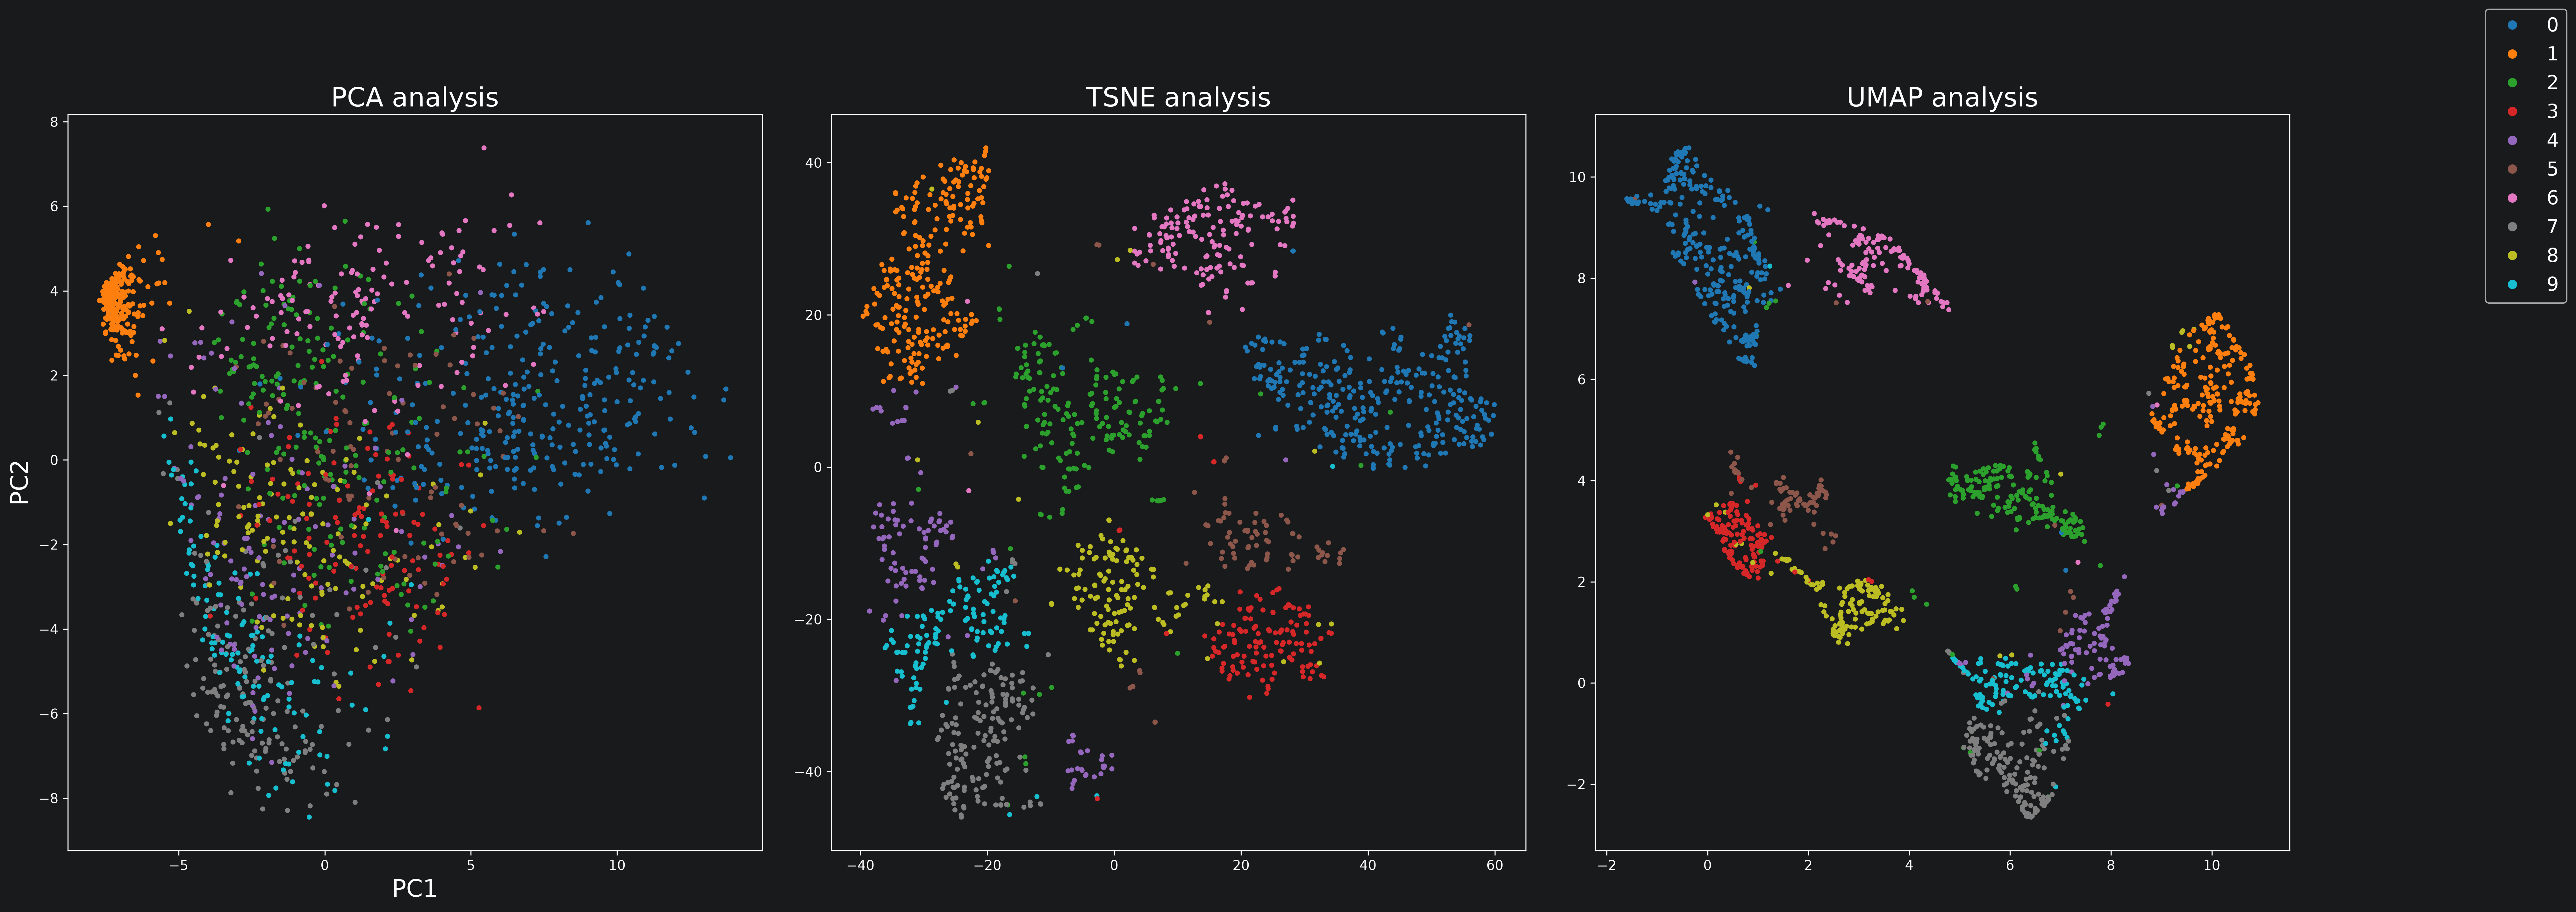

In [8]:
fig2 , axes2 = plt.subplots(1, 3,figsize=(30,10))


picture_pca = axes2[0].scatter(pca_analysis.iloc[:,0],pca_analysis.iloc[:,1],c =pca_analysis.iloc[:,2],cmap="tab10",s = 8)
axes2[0].set_title("PCA analysis",loc="center",fontsize=20)
axes2[0].set_xlabel("PC1",fontsize=18)
axes2[0].set_ylabel("PC2",fontsize=18)

axes2[1].scatter(tsne_analysis.iloc[:,0],tsne_analysis.iloc[:,1],c = tsne_analysis.iloc[:,2],cmap="tab10",s = 8)
axes2[1].set_title("TSNE analysis",loc="center",fontsize=20)


axes2[2].scatter(umap_analysis.iloc[:,0],umap_analysis.iloc[:,1],c = umap_analysis.iloc[:,2],cmap="tab10", s = 8)
axes2[2].set_title("UMAP analysis",loc="center",fontsize=20)


n = picture_pca.legend_elements()
fig2.legend(n[0],n[1],fontsize="x-large",bbox_to_anchor=(1,1))
fig2.subplots_adjust(wspace=0.1)
fig2.set_dpi(300)
plt.show()

# K-NN classification


In [9]:
from collections import Counter
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))
def mahalanobis_distance(point1,point2, inverse_of_covariance):
    diff = np.array(point1) - np.array(point2)
    return np.sqrt(diff @ inverse_of_covariance @ diff)

def knn_predict(training_data, training_labels, test_point, k, metric = "euclidean",inv_of_cov = None):
    distances = []
    if metric == "euclidean":
        for i in range(len(training_data)):
            dist = euclidean_distance(test_point, training_data[i])
            distances.append((dist, training_labels[i]))
    elif metric == "mahalanobis":
        for i in range(len(training_data)):
            dist = mahalanobis_distance(test_point, training_data[i],inverse_of_covariance = inv_of_cov)
            distances.append((dist, training_labels[i]))

    else:
        raise ValueError("Unknown metric\ncannot predict")
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]
k = 5

train_in_knn = train_in.to_numpy()
train_out_knn = train_out.to_numpy().ravel()
predictions = [knn_predict(train_in_knn, train_out_knn, point, k)
               for point in test_in.to_numpy()]



# K-NN with Euclidean as distance matrix

In [10]:
predictions_train = [knn_predict(train_in_knn, train_out_knn, point, k)
               for point in train_in.to_numpy()]
predictions = [knn_predict(train_in_knn, train_out_knn, point, k)
               for point in test_in.to_numpy()]

# K-NN with Mahalanobis as distance metric

In [11]:
inverse_of_cov_knn = np.linalg.inv(train_in_mahalanobis.cov() + (np.identity(train_in_mahalanobis.cov().shape[0])*9))
predictions_mahalanobis_train = [knn_predict(train_in_knn, train_out_knn , point, k, metric = "mahalanobis", inv_of_cov = inverse_of_cov_knn) for point in train_in.to_numpy()]
predictions_mahalanobis = [knn_predict(train_in_knn, train_out_knn , point, k, metric = "mahalanobis", inv_of_cov = inverse_of_cov_knn) for point in test_in.to_numpy()]

# Checking the accuracy

In [12]:
acc_knn = np.mean(np.array(predictions_train) == train_out["label"].to_numpy())
print("kNN accuracy(euclidean) on training set:", acc_knn)
acc_knn_mahalanobis = np.mean(np.array(predictions_mahalanobis_train) == train_out["label"].to_numpy())
print("kNN accuracy(mahalanobis) on training set:", acc_knn_mahalanobis)
print("-"*10)
acc_knn_test = np.mean(np.array(predictions) == test_out["label"].to_numpy())
print("kNN accuracy(euclidean) on test set:", acc_knn_test)
acc_knn_mahalanobis_test = np.mean(np.array(predictions_mahalanobis) == test_out["label"].to_numpy())
print("kNN accuracy(mahalanobis) on test set:", acc_knn_mahalanobis_test)

kNN accuracy(euclidean) on training set: 0.9730521382542472
kNN accuracy(mahalanobis) on training set: 0.9724663151728178
﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿

# Confusion matrix

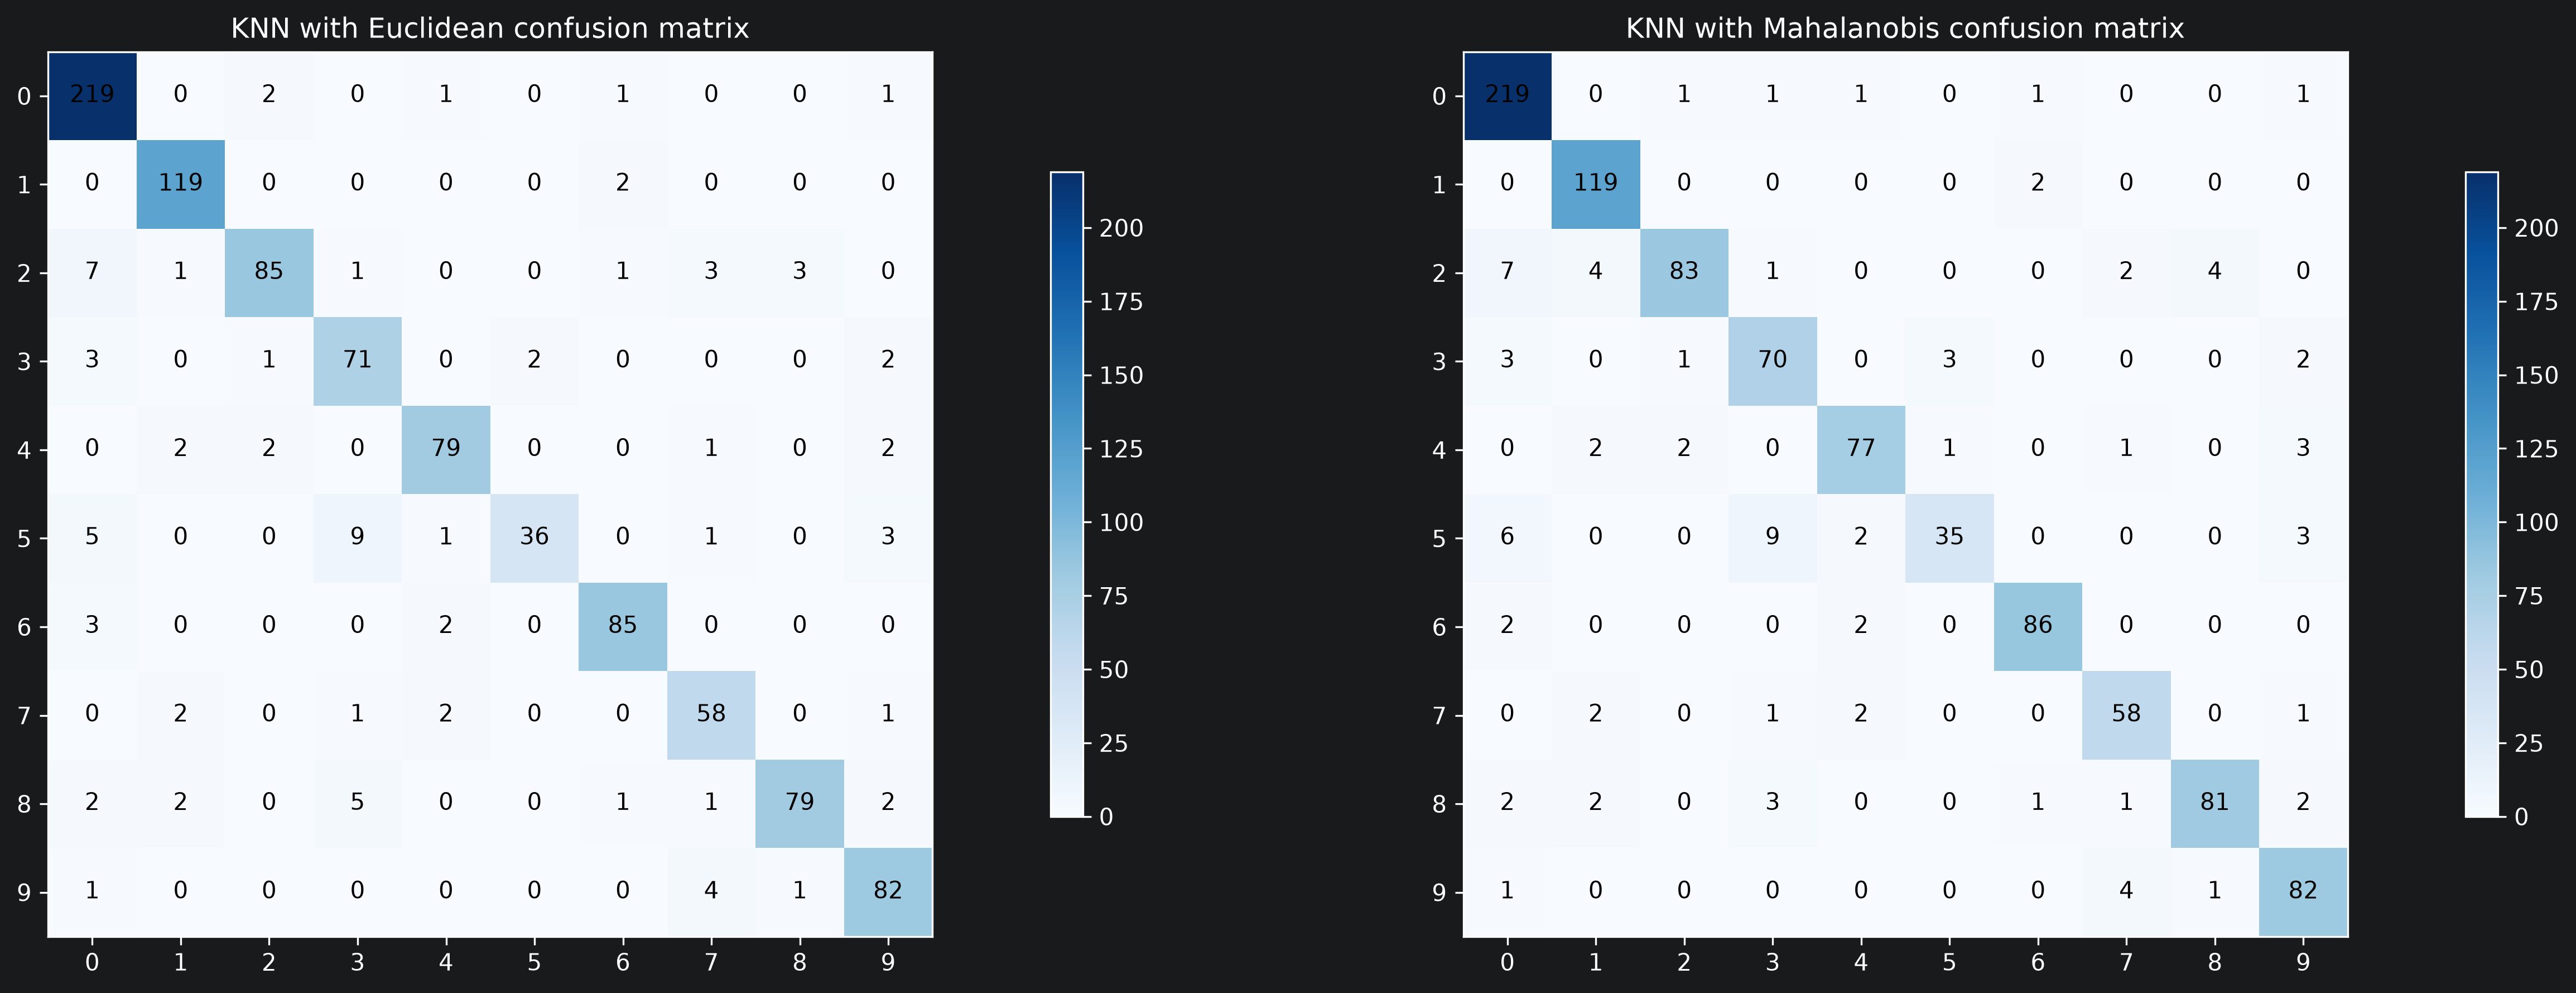

In [13]:
confusion_matrix_euclid_knn = pd.crosstab(test_set["label"], pd.Series(predictions))
confusion_matrix_mahala_knn = pd.crosstab(test_set["label"], pd.Series(predictions_mahalanobis))


fig3, axes3 = plt.subplots(1, 2,figsize=(20,10))

picture_euclid_knn = axes3[0].imshow(confusion_matrix_euclid_knn,cmap=plt.cm.Blues)
axes3[0].set_xticks(digits)
axes3[0].set_yticks(digits)
for x in digits:
    for y in digits:
        axes3[0].text(x,y,confusion_matrix_euclid_knn.iloc[y,x],color="black",ha="center",va="center")
fig3.colorbar(picture_euclid_knn, ax=axes3[0],pad=0.1,shrink=0.5)
axes3[0].set_title("KNN with Euclidean confusion matrix")

picture_mahala_knn = axes3[1].imshow(confusion_matrix_mahala_knn,cmap=plt.cm.Blues)
axes3[1].set_xticks(digits)
axes3[1].set_yticks(digits)
for x in digits:
    for y in digits:
        axes3[1].text(x,y,confusion_matrix_mahala_knn.iloc[y,x],color="black",ha="center",va="center")
fig3.colorbar(picture_mahala_knn, ax=axes3[1],pad= 0.1,shrink=0.5)
axes3[1].set_title("KNN with Mahalanobis confusion matrix")

fig3.subplots_adjust(wspace=0.2)
fig3.set_dpi(300)
plt.show()

# Task 2


In [15]:
from sklearn.preprocessing import OneHotEncoder
from math import log

def ReLU(x):
     return np.maximum(0, x)

def Softmax(x):
    shifted = x - np.max(x)
    return np.exp(shifted) / np.sum(np.exp(shifted))

# def Training(training_data, training_labels, test_data, test_labels, epoch = 100, random_seed = 42, nn_hidden_layers = 7, learning_rate = 0.001):
#     np.random.seed(random_seed)
#     training_data = training_data.to_numpy()
#     encoder = OneHotEncoder(sparse_output=False)
#     Y = encoder.fit_transform(training_labels.to_numpy().reshape(-1, 1))
#     Biases = np.zeros(nn_hidden_layers)
#     output_bias = np.ones(Y.shape[1])
#     Hidden_layer = np.random.randn(nn_hidden_layers,training_data.shape[1]) * np.sqrt(2/training_data.shape[1])
#     output_layer = np.random.randn(Y.shape[1],nn_hidden_layers) * np.sqrt(2/nn_hidden_layers)
#     accuracies = []
#     losses = []
#     X_test = test_data.to_numpy()
#     y_test = test_labels.to_numpy().ravel().astype(int)
#     test_accuracies = []
#     test_losses = []
#     for e in range(epoch):
#         counter = 0
#         total_loss = 0
#         correct = 0
#
#         for row, target in zip(training_data, Y):
#             counter += 1
#             into_hidden = (Hidden_layer @ row) + Biases
#             activated_hidden = ReLU(into_hidden)
#             into_output = (output_layer @ activated_hidden) + output_bias
#             probs = Softmax(into_output)
#             total_loss += -log(probs @ target)
#             #total_loss += np.sum((probs - target) ** 2)
#             if np.argmax(probs) == np.argmax(target):
#                 correct += 1
#             error_out = probs - target
#             #d = 2 * (probs - target)
#             #error_out = probs * (d - np.sum(d * probs))
#
#             error_hidden = output_layer.T @ error_out
#             error_hidden = error_hidden * (into_hidden > 0)
#
#             grad_output_bias  = error_out
#             grad_output_layer = np.outer(error_out, activated_hidden) + output_layer * 0.008
#             grad_hidden_bias  = error_hidden
#             grad_hidden_layer = np.outer(error_hidden, row) + Hidden_layer * 0.028
#
#             output_bias  -= learning_rate * grad_output_bias
#             output_layer -= learning_rate * grad_output_layer
#             Biases       -= learning_rate * grad_hidden_bias
#             Hidden_layer -= learning_rate * grad_hidden_layer
#
#         losses.append(total_loss/len(training_data))
#         accuracies.append(correct /len(training_data))
#         print(f"epoch {e+1:3d}/{epoch}  row {counter:5d}  "
#                   f"loss {total_loss/counter:.4f}  acc {correct/counter:.4f}",
#                   end="\r", flush=True)
#
#
#
#     X_test = test_data.to_numpy()
#     y_test = test_labels.to_numpy().ravel().astype(int)
#
#     test_loss = 0
#     test_correct = 0
#     for row, true_digit in zip(X_test, y_test):
#         into_hidden = (Hidden_layer @ row) + Biases
#         activated_hidden = ReLU(into_hidden)
#         into_output = (output_layer @ activated_hidden) + output_bias
#         probs = Softmax(into_output)
#
#         test_loss += -np.log(probs[true_digit])
#         if np.argmax(probs) == true_digit:
#             test_correct += 1
#
#     test_loss /= len(X_test)
#     test_accuracy = test_correct / len(X_test)
#     print(f"\ntest   loss {test_loss:.4f}  acc {test_accuracy:.4f}")
#
"""
Implemented a class from the old training loop also added more error handling for future use. Also updated the naming conventions to make more sense.
"""

class MLP:
    """A two-layer multi-layer perceptron trained with stochastic gradient descent."""

    def __init__(self, n_hidden=7, learning_rate=0.001, lam_hidden=0.028,
                 lam_output=0.008, loss="cross_entropy", random_seed=42):
        self.set_params(
            n_hidden=n_hidden,
            learning_rate=learning_rate,
            lam_hidden=lam_hidden,
            lam_output=lam_output,
            loss=loss,
            random_seed=random_seed,
        )
        self.history = {"train_loss": [], "train_acc": [],
                        "test_loss": [], "test_acc": []}
        self.classes_ = None
        self.Hidden_layer = None


    def set_params(self, **kwargs):
        """Change any parameter key:value style"""
        allowed = {"n_hidden", "learning_rate", "lam_hidden",
                   "lam_output", "loss", "random_seed"}
        for key, value in kwargs.items():
            if key not in allowed:
                raise ValueError(f"Unknown parameter: {key}. Allowed: {sorted(allowed)}")
            setattr(self, key, value)
        if self.loss not in ("cross_entropy", "mse"):
            raise ValueError("loss must be 'cross_entropy' or 'mse'")
        return self

    def get_params(self):
        return {key: getattr(self, key) for key in
                ("n_hidden", "learning_rate", "lam_hidden",
                 "lam_output", "loss", "random_seed")}

    def _init_weights(self, n_features, n_classes):
        np.random.seed(self.random_seed)
        self.Hidden_layer = np.random.randn(self.n_hidden, n_features) * np.sqrt(2 / n_features)
        self.Biases = np.zeros(self.n_hidden)
        self.output_layer = np.random.randn(n_classes, self.n_hidden) * np.sqrt(2 / self.n_hidden)
        self.output_bias = np.zeros(n_classes)

    @staticmethod
    def _as_array(data):
        return data.to_numpy() if hasattr(data, "to_numpy") else np.asarray(data)


    def _forward(self, row):
        into_hidden = self.Hidden_layer @ row + self.Biases
        activated_hidden = ReLU(into_hidden)
        into_output = self.output_layer @ activated_hidden + self.output_bias
        probs = Softmax(into_output)
        return into_hidden, activated_hidden, probs

    def _loss(self, probs, target):
        if self.loss == "cross_entropy":
            return -np.log(probs @ target)
        return np.sum((probs - target) ** 2)

    def _output_error(self, probs, target):
        if self.loss == "cross_entropy":
            return probs - target
        d = 2 * (probs - target)
        return probs * (d - np.sum(d * probs))


    def fit(self, X, y, epochs=100, test_data=None, test_labels=None, verbose=True):
        X = self._as_array(X)
        encoder = OneHotEncoder(sparse_output=False)
        Y = encoder.fit_transform(self._as_array(y).reshape(-1, 1))
        self.classes_ = encoder.categories_[0]

        self._init_weights(X.shape[1], Y.shape[1])
        self.history = {"train_loss": [], "train_acc": [],
                        "test_loss": [], "test_acc": []}

        for e in range(epochs):
            total_loss = 0.0
            correct = 0

            for row, target in zip(X, Y):
                into_hidden, activated_hidden, probs = self._forward(row)

                total_loss += self._loss(probs, target)
                if np.argmax(probs) == np.argmax(target):
                    correct += 1

                error_out = self._output_error(probs, target)
                error_hidden = (self.output_layer.T @ error_out) * (into_hidden > 0)

                grad_output_layer = np.outer(error_out, activated_hidden) + self.lam_output * self.output_layer
                grad_hidden_layer = np.outer(error_hidden, row) + self.lam_hidden * self.Hidden_layer

                self.output_bias -= self.learning_rate * error_out
                self.output_layer -= self.learning_rate * grad_output_layer
                self.Biases -= self.learning_rate * error_hidden
                self.Hidden_layer -= self.learning_rate * grad_hidden_layer

            self.history["train_loss"].append(total_loss / len(X))
            self.history["train_acc"].append(correct / len(X))

            line = (f"epoch {e + 1:3d}/{epochs}  "
                    f"loss {self.history['train_loss'][-1]:.4f}  "
                    f"acc {self.history['train_acc'][-1]:.4f}")

            if test_data is not None and test_labels is not None:
                t_loss, t_acc, _ = self.evaluate(test_data, test_labels)
                self.history["test_loss"].append(t_loss)
                self.history["test_acc"].append(t_acc)
                line += f"  |  test loss {t_loss:.4f}  test acc {t_acc:.4f}"

            if verbose:
                print(line + " " * 8, end="\r", flush=True)

        if verbose:
            print()
        return self


    def predict(self, X):
        if self.Hidden_layer is None:
            raise RuntimeError("Call fit() before predict().")
        X = self._as_array(X)
        return np.array([self.classes_[np.argmax(self._forward(row)[2])] for row in X])

    def evaluate(self, X, y):
        """Evaluate the training weights"""
        X = self._as_array(X)
        y = self._as_array(y).ravel()

        label_to_slot = {label: i for i, label in enumerate(self.classes_)}
        total_loss = 0.0
        correct = 0
        predictions = []

        for row, true_label in zip(X, y):
            _, _, probs = self._forward(row)
            slot = label_to_slot[true_label]

            target = np.zeros(len(self.classes_))
            target[slot] = 1.0
            total_loss += self._loss(probs, target)

            predicted = np.argmax(probs)
            predictions.append(self.classes_[predicted])
            if predicted == slot:
                correct += 1

        return total_loss / len(X), correct / len(X), np.array(predictions)




mlp = MLP(n_hidden=18, learning_rate=0.001, lam_hidden=0.028, lam_output=0.008)
mlp.fit(train_in, train_out, epochs=90, test_data=test_in, test_labels=test_out)

loss, acc, predictions = mlp.evaluate(test_in, test_out)
print(f"final test  loss {loss:.4f}  acc {acc:.4f}")


epoch  90/90  loss 0.1137  acc 0.9842  |  test loss 0.3691  test acc 0.9010        
final test  loss 0.3691  acc 0.9010


In [33]:
def Training(training_data, training_labels, test_data, test_labels, epoch = 100, random_seed = 42, learning_rate = 0.001):
    nn_hidden_layers = 10
    np.random.seed(random_seed)
    training_data = training_data.to_numpy()
    X = np.hstack([training_data, np.ones((training_data.shape[0],1))])
    encoder = OneHotEncoder(sparse_output=False)
    T = encoder.fit_transform(training_labels.to_numpy().reshape(-1, 1))
    y_train = np.argmax(T, axis=1)
    W = np.random.randn(X.shape[1],nn_hidden_layers) * np.sqrt(2/training_data.shape[1])
    accuracies = []
    losses = []
    X_test = np.hstack([test_data, np.ones((test_data.shape[0],1))])
    y_test = test_labels.to_numpy().ravel().astype(int)
    T_test = np.eye(10)[y_test]
    test_accuracies = []
    test_losses = []
    for e in range(epoch):
        A = X @ W
        Y = np.where(A>0 , 1 , 0)

        A_test = X_test @ W
        Y_test = np.where(A_test > 0, 1, 0)
        test_accuracies.append(np.mean(np.argmax(A_test, axis=1) == y_test))
        test_losses.append(np.mean((T_test - Y_test) ** 2))
        accuracies.append(np.mean(np.argmax(A, axis=1) == y_train))
        losses.append(np.mean((T - Y) ** 2))
        W += learning_rate * X.T @ (T - Y)

        print(f"epoch {e+1:3d}/{epoch}  loss {losses[-1]:.4f}  acc {accuracies[-1]:.4f}  "
              f"test acc {test_accuracies[-1]:.4f}", end="\r", flush=True)

    print()
    return W, losses, accuracies, test_losses, test_accuracies   





Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 88, learning_rate = 0.001);

epoch 100/100  loss 0.0066  acc 0.9795  test acc 0.8890


In [45]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 42, learning_rate = 0.001);

epoch 100/100  loss 0.0082  acc 0.9783  test acc 0.8820


In [46]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 518, learning_rate = 0.001);

epoch 100/100  loss 0.0093  acc 0.9619  test acc 0.8700


In [47]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 2251, learning_rate = 0.001);



epoch 100/100  loss 0.0091  acc 0.9725  test acc 0.8820


In [49]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 221, learning_rate = 0.001);

epoch 100/100  loss 0.0068  acc 0.9777  test acc 0.8900


In [50]:
Training(train_in,train_out,test_in,test_out,epoch = 100, random_seed = 188, learning_rate = 0.001);

epoch 100/100  loss 0.0087  acc 0.9754  test acc 0.8940
